# 14 — Multi-Panel Publication Figures

Each cell writes one figure directly in matplotlib; shared chrome is in `gtex_biomarkers.figure_builder`. Outputs: `figure_{2..6}.{pdf,png,svg}` (600 dpi); Fig 1 is authored externally in BioRender.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from scipy.stats import spearmanr

from gtex_biomarkers.config import Config
from gtex_biomarkers.figure_builder import (
    apply_style, save_fig, panel_letter, thin_spines, short_pair, load_data,
    CORAL, STEEL, SAGE, GOLD, SLATE, GRAY, GRAY_LT,
    CMAP_AUC, CMAP_NES, CMAP_RANK,
)

Config.ensure_dirs()
apply_style()
data = load_data()

# Unpack into module-level names so each figure cell can use them directly
lr         = data["lr"]
rf         = data["rf"]
three      = data["three"]
three_top  = data["three_top"]
conf_imp   = data["conf_imp"]
pc_auc     = data["pc_auc"]
pc_auc_top = data["pc_auc_top"]
pc_imp     = data["pc_imp"]
pc_vs_rf   = data["pc_vs_rf"]
gsea       = data["gsea"]
pca_cv     = data["pca_cv"]

print(f"loaded: LR={len(lr)}  RF={len(rf)}  three={len(three)} (top15={len(three_top)})  "
      f"PC={len(pc_auc)} (top9={len(pc_auc_top)})  GSEA={len(gsea)}  "
      f"PCA_PC100={pca_cv.loc[pca_cv['pc']==100,'cum_var'].iloc[0]*100:.1f}%")

loaded: LR=59  RF=59  three=59 (top15=14)  PC=59 (top9=4)  GSEA=319  PCA_PC100=84.3%


# Figure 2 — Cohort structure and confounder landscape (composed in BioRender)

Panel B (this cell) writes the PC1×PC2 scatter coloured by 5 clinical covariates as `figure_2B.svg`; composed with the BioRender anatomy Panel A into `figure_2.pdf`.

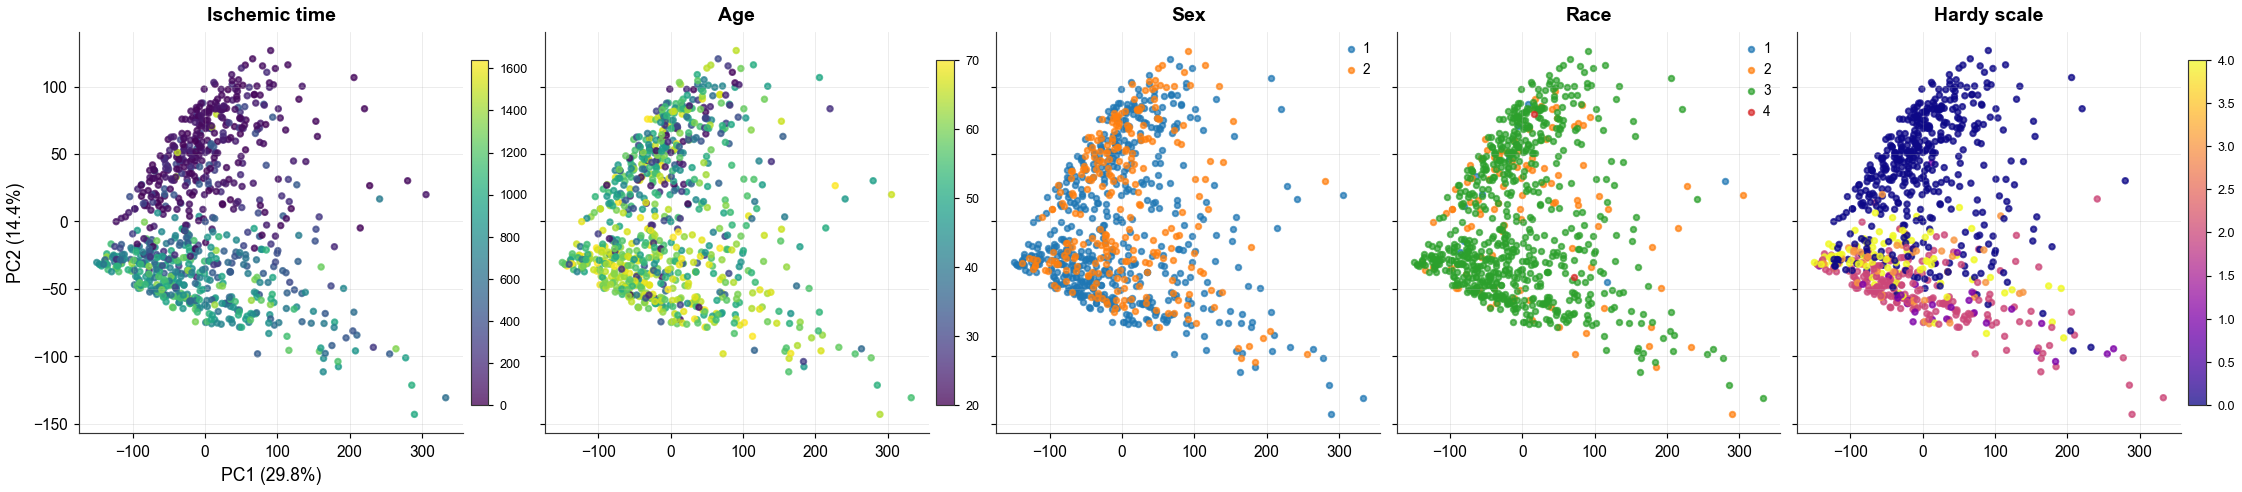

Saved standalone Fig 2B:
  /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/output/figures/figure_2B.svg   <- import this into BioRender below Panel A
  /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/output/figures/figure_2B.pdf   (backup, fully vector)
  /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/output/figures/figure_2B.png   (600 dpi preview)


In [2]:
# Fig 2 is composed in BioRender to stay fully vector: Panel A (anatomy, authored in BioRender) + Panel B (this cell's SVG). Keep SVG text as editable text so BioRender can restyle.
plt.rcParams["svg.fonttype"] = "none"

# Load PC scores + explained variance (from NB10 §10.1c)
donor_scores = pd.read_csv(Config.TABLES_DIR / "pca_donor_scores_wb20k.csv",
                           index_col=0)
_ve = pd.read_csv(Config.TABLES_DIR / "pca_explained_variance_top10.csv")
pc1_var = _ve.iloc[0]["var_ratio"] * 100
pc2_var = _ve.iloc[1]["var_ratio"] * 100

# (covariate_col, display_label, cmap, is_categorical)
COV_SPECS = [
    ("TRISCHD", "Ischemic time", "viridis", False),
    ("AGE",     "Age",           "viridis", False),
    ("SEX",     "Sex",           None,      True),
    ("RACE",    "Race",          None,      True),
    ("DTHHRDY", "Hardy scale",   "plasma",  False),
]

# --- Layout: 1 row × 5 subpanels sized as a wide strip for BioRender canvas
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5),
                         sharex=True, sharey=True, constrained_layout=True)

for ax, (col, label, cmap, is_cat) in zip(axes, COV_SPECS):
    if is_cat:
        for v in sorted(donor_scores[col].dropna().unique()):
            sub = donor_scores[donor_scores[col] == v]
            ax.scatter(sub["PC1"], sub["PC2"], s=8, alpha=0.7,
                       label=f"{v:g}")
        ax.legend(fontsize=7, frameon=False, loc="best",
                  handletextpad=0.3, borderaxespad=0.3)
    else:
        sc = ax.scatter(donor_scores["PC1"], donor_scores["PC2"],
                        s=8, alpha=0.75, c=donor_scores[col], cmap=cmap)
        fig.colorbar(sc, ax=ax, fraction=0.045, pad=0.02)
    ax.set_title(label, fontsize=10)
    ax.tick_params(axis="both", labelsize=8)
    ax.grid(True, alpha=0.3, lw=0.4)
    thin_spines(ax)
axes[0].set_xlabel(f"PC1 ({pc1_var:.1f}%)", fontsize=9)
axes[0].set_ylabel(f"PC2 ({pc2_var:.1f}%)", fontsize=9)

# --- Save: SVG for BioRender import + PDF/PNG for preview -------------------
FIG2B_STEM = Config.FIGURES_DIR / "figure_2B"
fig.savefig(f"{FIG2B_STEM}.svg", bbox_inches="tight")
fig.savefig(f"{FIG2B_STEM}.pdf", bbox_inches="tight")
fig.savefig(f"{FIG2B_STEM}.png", bbox_inches="tight", dpi=600)
plt.show()
print("Saved standalone Fig 2B:")
print(f"  {FIG2B_STEM}.svg   <- import this into BioRender below Panel A")
print(f"  {FIG2B_STEM}.pdf   (backup, fully vector)")
print(f"  {FIG2B_STEM}.png   (600 dpi preview)")

# Figure 3 — Modeling: Liver | Cirrhosis Case Study and Qualifying Pairs

A: Top-10 PCs by univariate CV AUC. B: 4-model AUC comparison. C: covariates-only vs PC+covariates paired bars for qualifying pairs. D: matching ΔAUC lollipop.

  saved figure_3.pdf  (47 KB)


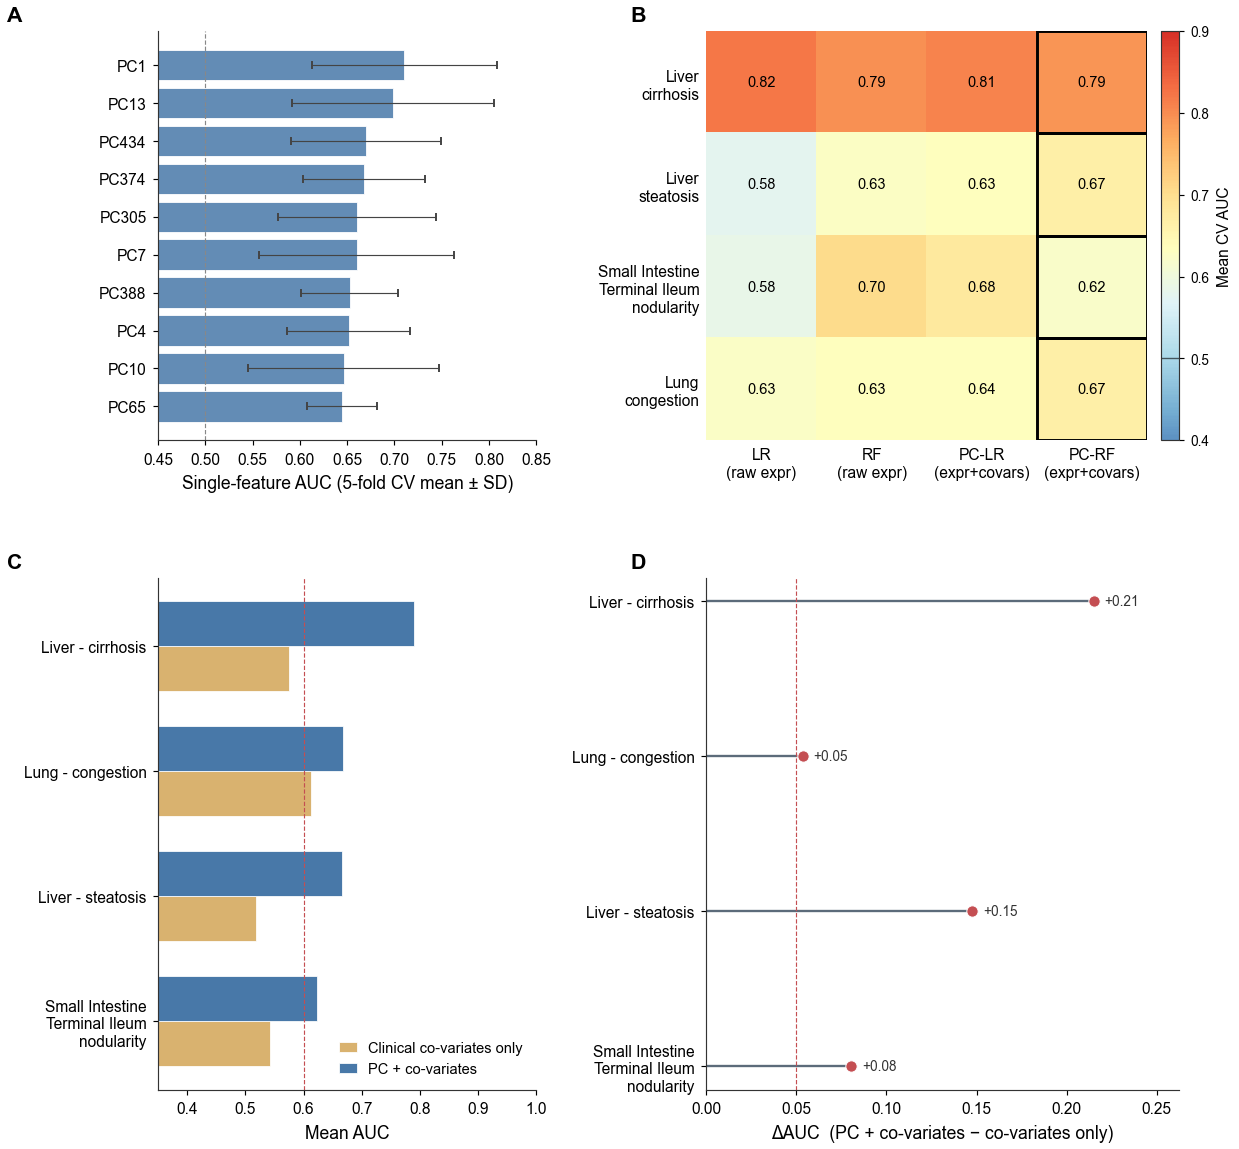

In [3]:
uv_df    = pd.read_csv(Config.TABLES_DIR / "liver_cirrhosis_pc_univariate_auc.csv")
pc_rf    = pd.read_csv(Config.TABLES_DIR / "pc_auc_results.csv")

# Panel B data: 4-pathology x 4-model heatmap (headline model highlighted).
heat_df  = pd.read_csv(Config.TABLES_DIR / "six_model_auc_matrix_mean.csv", index_col=0)
HEAT_COLS = ["LR raw", "RF raw", "PC-LR (expr+covars)", "PC-RF (expr+covars)"]
HEAT_LABELS = {
    "LR raw":              "LR\n(raw expr)",
    "RF raw":              "RF\n(raw expr)",
    "PC-LR (expr+covars)": "PC-LR\n(expr+covars)",
    "PC-RF (expr+covars)": "PC-RF\n(expr+covars)",
}
HEADLINE_HEAT_COL = "PC-RF (expr+covars)"
heat_df = heat_df[HEAT_COLS]

# PC-qualifying pairs (auc_pc_conf >= Config.AUC_THRESH AND delta_pc >= Config.DELTA_THRESH)
qualifying = (pc_rf[(pc_rf["auc_pc_conf"] >= Config.AUC_THRESH) & (pc_rf["delta_pc"] >= Config.DELTA_THRESH)]
              .assign(label=lambda d: [short_pair(t, c)
                                        for t, c in zip(d["tissue"], d["category"])])
              .sort_values("auc_pc_conf", ascending=False)
              .reset_index(drop=True))

# Wrap any qualifying-pair label > 22 chars at its last ' - ' so
# long tissue names (e.g. 'Small Intestine - Terminal Ileum - nodularity')
# do not overlap the next panel in C/D.
def wrap_long(label, max_len=22):
    """Stack long ' - '-separated labels onto one segment per line."""
    if len(label) <= max_len:
        return label
    return '\n'.join(s.strip() for s in label.split(' - '))

qual_labels = [wrap_long(l) for l in qualifying['label']]

# --- Layout ------------------------------------------------------------------
fig = plt.figure(figsize=(9.0, 8.4))
gs = GridSpec(2, 2, figure=fig,
              height_ratios=[1.0, 1.25], width_ratios=[1.0, 1.25],
              hspace=0.30, wspace=0.40,
              left=0.16, right=0.97, top=0.97, bottom=0.07)

LABEL_FS = 9
TICK_FS  = 8
LEG_FS   = 7.5

# ============================================================== A top 10 PCs
axA = fig.add_subplot(gs[0, 0])
top10 = uv_df.head(10).iloc[::-1].reset_index(drop=True)
y = np.arange(len(top10))
axA.barh(y, top10["mean_auc"], xerr=top10["std_auc"],
         color=STEEL, alpha=0.85, edgecolor="white", lw=0.5,
         error_kw=dict(lw=0.6, capsize=2, ecolor="#444"))
axA.axvline(0.5, color=GRAY, ls="--", lw=0.6)
axA.set_yticks(y)
axA.set_yticklabels([f"PC{int(p)}" for p in top10["pc"]], fontsize=TICK_FS)
axA.tick_params(axis="x", labelsize=TICK_FS)
axA.set_xlabel("Single-feature AUC (5-fold CV mean ± SD)", fontsize=LABEL_FS)
axA.set_xlim(0.45, max(0.85, (top10["mean_auc"] + top10["std_auc"]).max() * 1.02))
thin_spines(axA)

# ============================================================== B 4-pathology x 4-model heatmap
# Cross-pathology model comparison. Headline model PC-RF (expr+covars) is boxed.
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable

axB = fig.add_subplot(gs[0, 1])
_base = mpl.colormaps["RdYlBu_r"]
_cmap = LinearSegmentedColormap.from_list(
    "RdYlBu_r_trunc", _base(np.linspace(0.15, 0.90, 256)))
_norm = mpl.colors.Normalize(vmin=0.40, vmax=0.90)

def _stacked(s):
    return "\n".join(s.split(" - "))
def _text_color(v):
    r, g, b, _ = _cmap(_norm(v))
    return "black" if (0.299*r + 0.587*g + 0.114*b) > 0.55 else "white"

_vals = heat_df.to_numpy()
_n_rows, _n_cols = _vals.shape
_im = axB.imshow(_vals, cmap=_cmap, norm=_norm, aspect="auto")
for _i in range(_n_rows):
    for _j in range(_n_cols):
        axB.text(_j, _i, f"{_vals[_i, _j]:.2f}",
                 ha="center", va="center", fontsize=7.5,
                 color=_text_color(_vals[_i, _j]))
_hl_j = HEAT_COLS.index(HEADLINE_HEAT_COL)
for _i in range(_n_rows):
    axB.add_patch(Rectangle((_hl_j - 0.5, _i - 0.5), 1.0, 1.0,
                            fill=False, edgecolor="black",
                            linewidth=1.5, zorder=5))
axB.set_xticks(range(_n_cols))
axB.set_xticklabels([HEAT_LABELS[c] for c in HEAT_COLS],
                    fontsize=TICK_FS, linespacing=1.25)
axB.set_yticks(range(_n_rows))
axB.set_yticklabels([_stacked(s) for s in heat_df.index],
                    fontsize=TICK_FS, linespacing=1.25)
axB.tick_params(axis="both", which="both", length=0)
for _sp in axB.spines.values():
    _sp.set_visible(False)
axB.set_ylim(_n_rows - 0.5, -0.5)

# Colorbar attached to axB (right side, thin)
_div = make_axes_locatable(axB)
_cax = _div.append_axes("right", size="4%", pad=0.10)
_cbar = fig.colorbar(_im, cax=_cax)
_cbar.set_label("Mean CV AUC", fontsize=LABEL_FS - 1)
_cbar.set_ticks([0.40, 0.50, 0.60, 0.70, 0.80, 0.90])
_cbar.ax.tick_params(labelsize=TICK_FS - 1)
_cbar.ax.axhline(0.50, color="black", linewidth=0.7, alpha=0.6)

# ============================================================== C qualifying pairs — paired bars
axC = fig.add_subplot(gs[1, 0])
y_pos = np.arange(len(qualifying))[::-1]
h = 0.36
axC.barh(y_pos - h/2, qualifying["auc_conf"], h, color=GOLD,
         edgecolor="white", lw=0.4, label="Clinical co-variates only")
axC.barh(y_pos + h/2, qualifying["auc_pc_conf"], h, color=STEEL,
         edgecolor="white", lw=0.4, label="PC + co-variates")
axC.axvline(0.60, color=CORAL, ls="--", lw=0.6)
axC.set_yticks(y_pos)
axC.set_yticklabels(qual_labels, fontsize=TICK_FS)
axC.tick_params(axis="x", labelsize=TICK_FS)
axC.set_xlim(0.35, 1.0)
axC.set_xlabel("Mean AUC", fontsize=LABEL_FS)
axC.legend(loc="lower right", fontsize=LEG_FS, frameon=False, handlelength=1.2)
thin_spines(axC)

# ============================================================== D qualifying pairs — Δ lollipop
axD = fig.add_subplot(gs[1, 1])
axD.hlines(y_pos, 0, qualifying["delta_pc"], color=SLATE, lw=1.2)
axD.scatter(qualifying["delta_pc"], y_pos, s=34, color=CORAL,
            edgecolor="white", linewidth=0.5, zorder=3)
for yi, v in zip(y_pos, qualifying["delta_pc"]):
    axD.text(v + 0.006, yi, f"+{v:.2f}", va="center",
             fontsize=7.0, color="#333")
axD.axvline(0, color="black", lw=0.5)
axD.axvline(0.05, color=CORAL, ls="--", lw=0.6)
axD.set_yticks(y_pos)
axD.set_yticklabels(qual_labels, fontsize=TICK_FS)
axD.tick_params(axis="x", labelsize=TICK_FS)
axD.set_xlim(0, qualifying["delta_pc"].max() * 1.22)
axD.set_xlabel("ΔAUC  (PC + co-variates − co-variates only)", fontsize=LABEL_FS)
thin_spines(axD)

# Panel letters
LETTER_X = 0.04
fig.text(LETTER_X, axA.get_position().y1 + 0.005, "A",
         fontsize=11, fontweight="bold", va="bottom", ha="left")
fig.text(LETTER_X, axC.get_position().y1 + 0.005, "C",
         fontsize=11, fontweight="bold", va="bottom", ha="left")
fig.text(axB.get_position().x0 - 0.06, axB.get_position().y1 + 0.005, "B",
         fontsize=11, fontweight="bold", va="bottom", ha="left")
fig.text(axD.get_position().x0 - 0.06, axD.get_position().y1 + 0.005, "D",
         fontsize=11, fontweight="bold", va="bottom", ha="left")

save_fig(fig, "figure_3.pdf"); plt.show()


# Figure 4 — Liver | Cirrhosis Case Study: From PCs to Genes to Pathways

A: top-10 PCs by Gini. B: top-10 back-projected genes. C: top-10 KEGG pathways by NES. D: top-10 Reactome pathways by NES — same PC-RF model drives all four panels.

  saved figure_4.pdf  (47 KB)


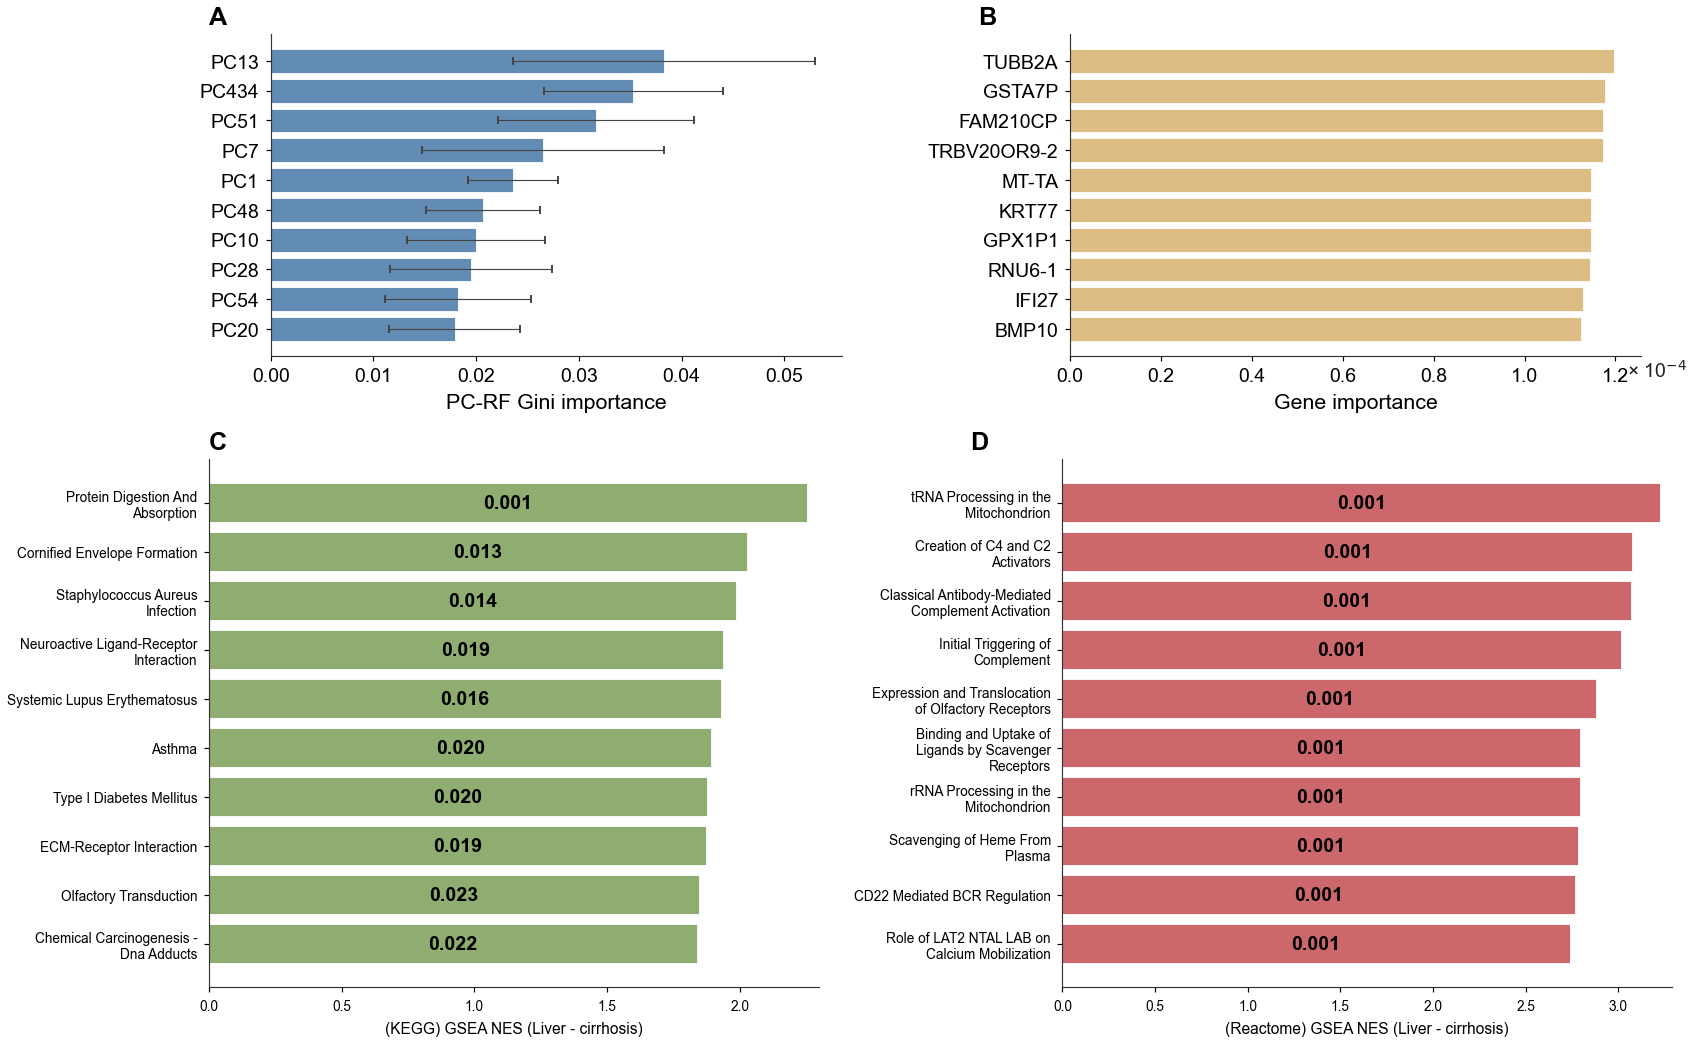

In [4]:
import textwrap

gini_df = pd.read_csv(Config.TABLES_DIR / "liver_cirrhosis_pc_rf_gini.csv")
gene_df = pd.read_csv(Config.TABLES_DIR / "pc_gene_importance_full.csv")
gsea_df = pd.read_csv(Config.TABLES_DIR / "gsea_pathway_enrichment.csv")

# Top 10 PCs (by mean Gini)
top10_pc = gini_df.head(10).iloc[::-1].reset_index(drop=True)

# Top 10 genes for Liver | cirrhosis (named only — drop ENSG-prefixed unannotated)
liv_genes = (gene_df[(gene_df["tissue"] == "Liver") & (gene_df["category"] == "cirrhosis")]
               .sort_values("importance", ascending=False))
liv_named = liv_genes[~liv_genes["gene_name"].str.startswith("ENSG")]
top10_gene = liv_named.head(10).iloc[::-1].reset_index(drop=True)

# Top 10 KEGG pathways (by NES) for Liver | cirrhosis
top10_kegg = (gsea_df[(gsea_df["tissue"] == "Liver")
                      & (gsea_df["category"] == "cirrhosis")
                      & (gsea_df["library"] == "KEGG_2026")]
                .sort_values("nes", ascending=False)
                .head(10)
                .iloc[::-1]
                .reset_index(drop=True))
_kegg_pretty = top10_kegg["pathway"].str.title().str.replace("Ecm-", "ECM-")
top10_kegg["pathway_pretty"] = _kegg_pretty.apply(
    lambda s: textwrap.fill(s, width=28, break_long_words=False)
)

# Top 10 Reactome pathways (by NES) for Liver | cirrhosis
top10_react = (gsea_df[(gsea_df["tissue"] == "Liver")
                       & (gsea_df["category"] == "cirrhosis")
                       & (gsea_df["library"] == "Reactome_Pathways_2024")]
                 .sort_values("nes", ascending=False)
                 .drop_duplicates(subset="pathway", keep="first")
                 .head(10)
                 .iloc[::-1]
                 .reset_index(drop=True))
_react_pretty = top10_react["pathway"]
top10_react["pathway_pretty"] = _react_pretty.apply(
    lambda s: textwrap.fill(s, width=28, break_long_words=False)
)

# --- Layout -----------------------------------------------------------------
# Two separate GridSpecs so the top row (A|B) and bottom row (C|D) don't
# share column boundaries — each row gets its own positioning to fit its
# content (short labels in A/B, long pathway labels in C/D).
fig = plt.figure(figsize=(11.0, 7.4))

gsTop = fig.add_gridspec(1, 2,
                         left=0.08, right=0.97, top=0.97, bottom=0.66,
                         wspace=0.40)
gsBot = fig.add_gridspec(1, 2,
                         left=0.04, right=0.99, top=0.56, bottom=0.05,
                         wspace=0.40)

# Distinct font sizes per row pair (C/D smaller — long pathway labels need
# more horizontal room, and they're a step "downstream" in the A→B→C/D chain)
LABEL_FS_AB = 11
TICK_FS_AB  = 10
LABEL_FS_CD = 8
TICK_FS_CD  = 7

# ============================================================== A — PC-RF Gini
axA = fig.add_subplot(gsTop[0, 0])
y = np.arange(len(top10_pc))
axA.barh(y, top10_pc["mean_gini"], xerr=top10_pc["std_gini"],
         color=STEEL, alpha=0.85, edgecolor="white", lw=0.5,
         error_kw=dict(lw=0.6, capsize=2, ecolor="#444"))
axA.set_yticks(y)
axA.set_yticklabels([f"PC{int(p)}" for p in top10_pc["pc"]], fontsize=TICK_FS_AB)
axA.tick_params(axis="x", labelsize=TICK_FS_AB)
axA.set_xlabel("PC-RF Gini importance", fontsize=LABEL_FS_AB)
thin_spines(axA)

# ============================================================== B — Gene importance
# Multiply by 1e4 and put the scaling in the axis label so the reader sees
# the units inline rather than as a floating corner annotation.
axB = fig.add_subplot(gsTop[0, 1])
y = np.arange(len(top10_gene))
axB.barh(y, top10_gene["importance"] * 1e4,
         color=GOLD, alpha=0.85, edgecolor="white", lw=0.5)
axB.set_yticks(y)
axB.set_yticklabels(top10_gene["gene_name"], fontsize=TICK_FS_AB)
axB.tick_params(axis="x", labelsize=TICK_FS_AB)
axB.set_xlabel("Gene importance", fontsize=LABEL_FS_AB)
# Place the unit multiplier just past the rightmost tick at tick-label height,
axB.text(1.08, -0.01, "× 10$^{-4}$", transform=axB.transAxes,
         fontsize=TICK_FS_AB, ha="right", va="top", color="#222")
thin_spines(axB)

# ============================================================== C — KEGG NES
# KEGG bars use SAGE (green); Reactome uses CORAL — different colors per
# library so the two panels are visually distinct in print.
axC = fig.add_subplot(gsBot[0, 0])
y = np.arange(len(top10_kegg))
colors_c = [SAGE if f < 0.05 else GRAY for f in top10_kegg["fdr"]]
axC.barh(y, top10_kegg["nes"], color=colors_c, alpha=0.85,
         edgecolor="white", lw=0.5)
for yi, n, f in zip(y, top10_kegg["nes"], top10_kegg["fdr"]):
    axC.text(n / 2, yi, f"{f:.3f}", va="center", ha="center",
             fontsize=TICK_FS_CD + 3, color="black", fontweight="bold")
axC.set_yticks(y)
axC.set_yticklabels(top10_kegg["pathway_pretty"], fontsize=TICK_FS_CD)
axC.tick_params(axis="x", labelsize=TICK_FS_CD)
axC.set_xlabel("(KEGG) GSEA NES (Liver - cirrhosis)", fontsize=LABEL_FS_CD)
axC.set_xlim(0, top10_kegg["nes"].max() * 1.02)
thin_spines(axC)

# ============================================================== D — Reactome NES
axD = fig.add_subplot(gsBot[0, 1])
y = np.arange(len(top10_react))
colors_d = [CORAL if f < 0.05 else GRAY for f in top10_react["fdr"]]
axD.barh(y, top10_react["nes"], color=colors_d, alpha=0.85,
         edgecolor="white", lw=0.5)
for yi, n, f in zip(y, top10_react["nes"], top10_react["fdr"]):
    axD.text(n / 2, yi, f"{f:.3f}", va="center", ha="center",
             fontsize=TICK_FS_CD + 3, color="black", fontweight="bold")
axD.set_yticks(y)
axD.set_yticklabels(top10_react["pathway_pretty"], fontsize=TICK_FS_CD)
axD.tick_params(axis="x", labelsize=TICK_FS_CD)
axD.set_xlabel("(Reactome) GSEA NES (Liver - cirrhosis)", fontsize=LABEL_FS_CD)
axD.set_xlim(0, top10_react["nes"].max() * 1.02)
thin_spines(axD)

# Panel letters
LETTER_X = 0.04
fig.text(LETTER_X, axA.get_position().y1 + 0.005, "A",
         fontsize=13, fontweight="bold", va="bottom", ha="left")
fig.text(axB.get_position().x0 - 0.06, axB.get_position().y1 + 0.005, "B",
         fontsize=13, fontweight="bold", va="bottom", ha="left")
fig.text(LETTER_X, axC.get_position().y1 + 0.005, "C",
         fontsize=13, fontweight="bold", va="bottom", ha="left")
fig.text(axD.get_position().x0 - 0.06, axD.get_position().y1 + 0.005, "D",
         fontsize=13, fontweight="bold", va="bottom", ha="left")

save_fig(fig, "figure_4.pdf"); plt.show()

# Figure 5 — Two-sample Mendelian randomization for Liver-cirrhosis

Faceted forest plot of top-15 Liver-cirrhosis candidates by p_MR: (A) causal drivers (same-direction MR); (B) causal protective (opposite-direction MR).

  saved figure_5.pdf  (56 KB)


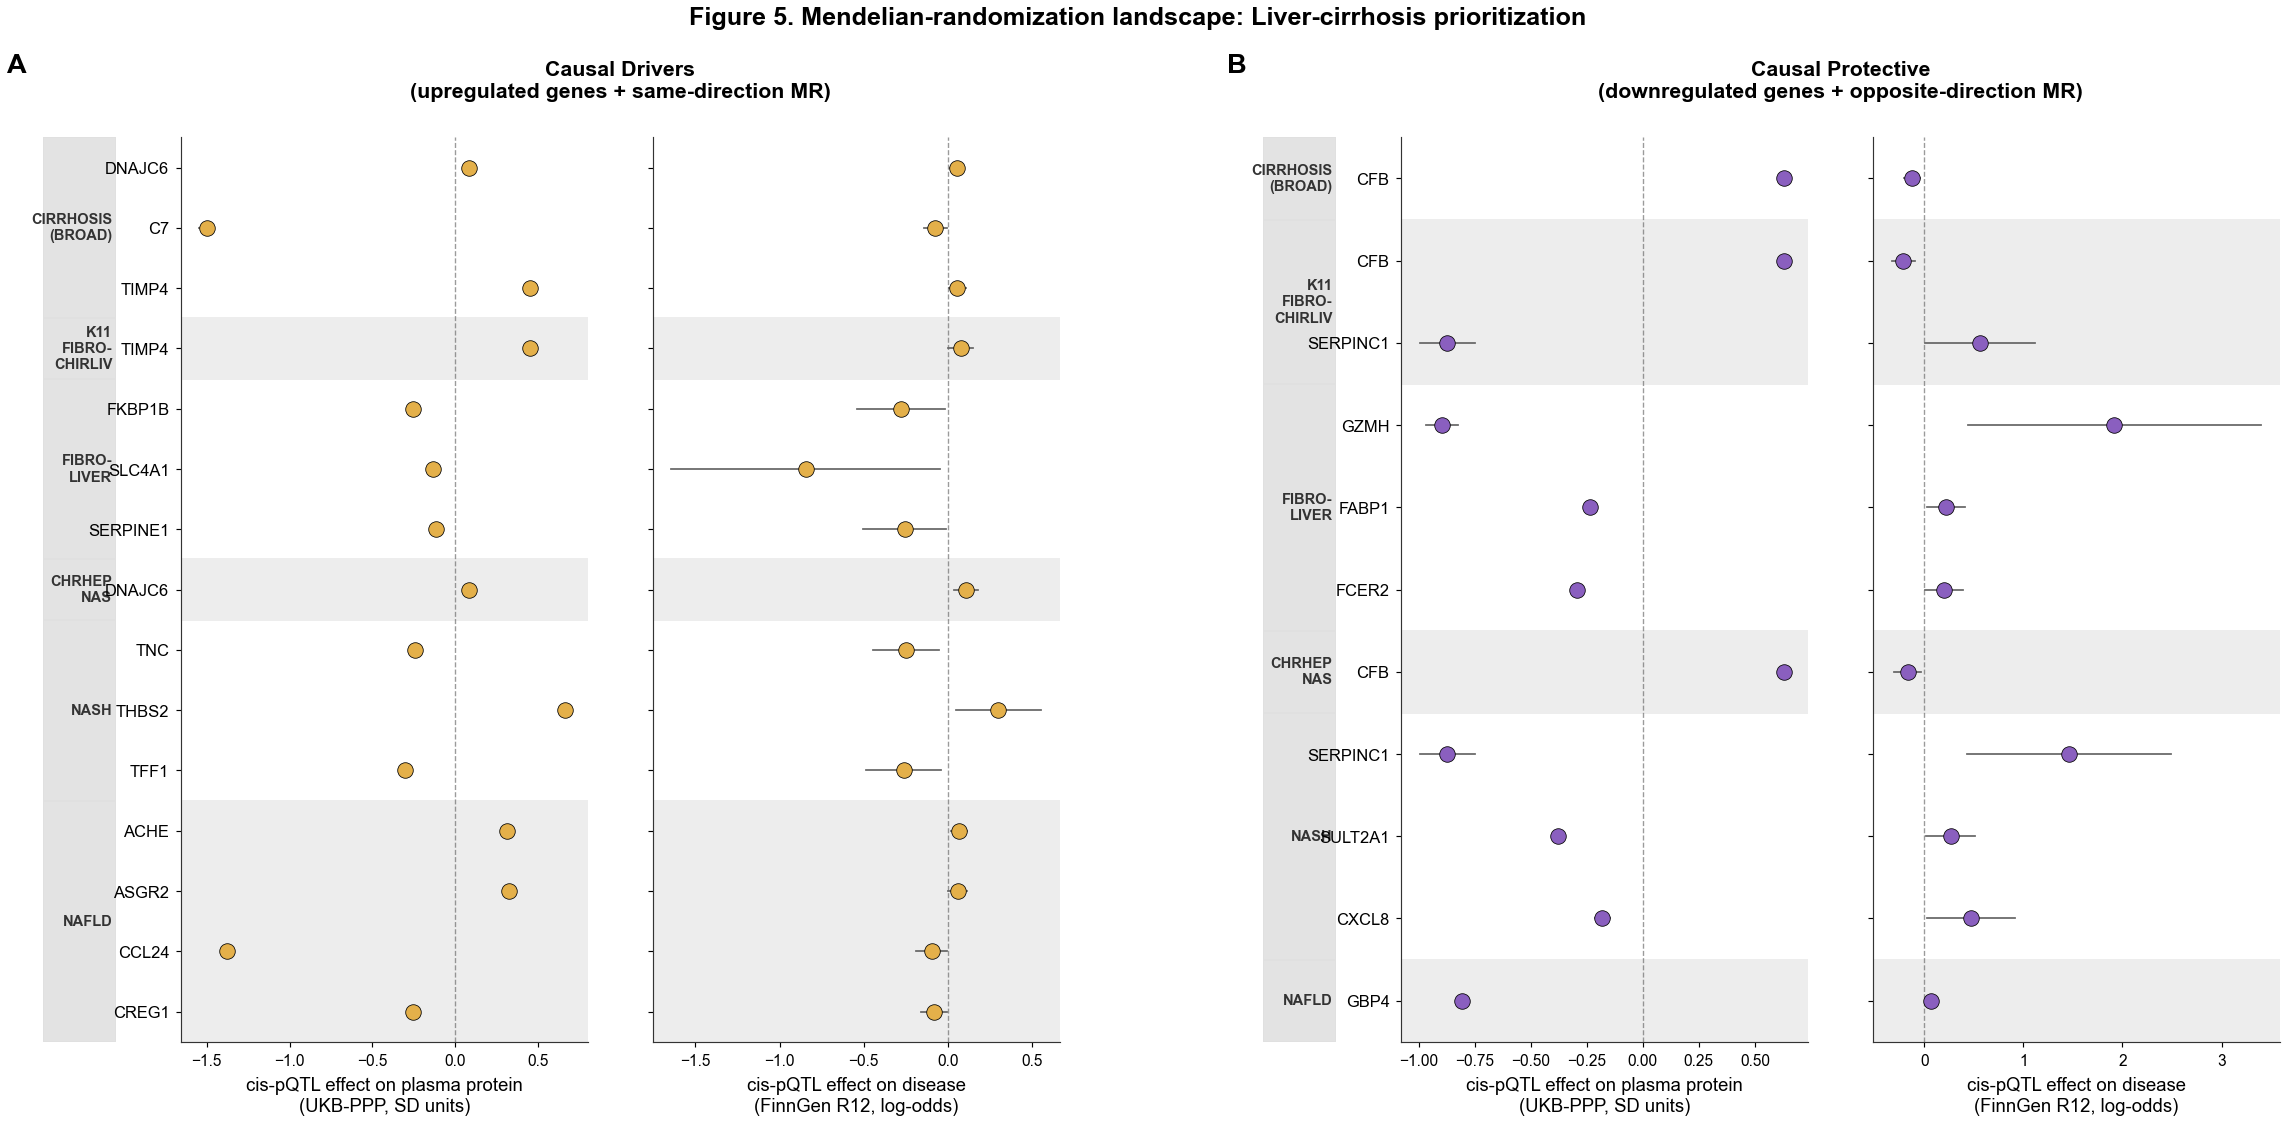

In [5]:
ST7_FILE = Config.RAW_DIR / "41586_2023_6592_MOESM3_ESM.xlsx"

mr_drv_raw = pd.read_csv(Config.TABLES_DIR / "mr_blood_cirrhosis_up100_same_direction.csv")
mr_prt_raw = pd.read_csv(Config.TABLES_DIR / "mr_blood_cirr_down_opposite_direction.csv")

# Filter to nominally significant + take top 15 by p_MR
sig_drv = mr_drv_raw[mr_drv_raw.p_MR < 0.05].sort_values("p_MR").head(15).reset_index(drop=True)
sig_prt = mr_prt_raw[mr_prt_raw.p_MR < 0.05].sort_values("p_MR").head(15).reset_index(drop=True)

st9 = pd.read_excel(ST7_FILE, sheet_name="ST9", header=4)
st9["gene_symbol"] = st9["UKBPPP ProteinID"].astype(str).str.split(":").str[0]
SE_EXP = (st9[st9["cis/trans"] == "cis"]
          .drop_duplicates("gene_symbol")
          .set_index("gene_symbol")["SE (discovery)"].to_dict())

MR_ORDER = ["NAFLD", "NASH", "CHIRHEP_NAS", "FIBROLIV", "K11_FIBROCHIRLIV", "CIRRHOSIS_BROAD"]
MR_LABEL = {
    "NAFLD": "NAFLD",
    "NASH": "NASH",
    "CHIRHEP_NAS": "CHRHEP\nNAS",
    "FIBROLIV": "FIBRO-\nLIVER",
    "K11_FIBROCHIRLIV": "K11\nFIBRO-\nCHIRLIV",
    "CIRRHOSIS_BROAD": "CIRRHOSIS\n(BROAD)",
}

def _sort_by_phen(mr):
    """Order rows so that CIRRHOSIS_BROAD is at top of the plot, NAFLD at bottom."""
    ord_map = {p: i for i, p in enumerate(MR_ORDER)}
    d = mr.copy()
    d["_ord"] = d["Phenotype"].map(ord_map)
    d = d.sort_values(["_ord", "p_MR"], ascending=[True, False])
    return d.reset_index(drop=True)

sig_drv_ord = _sort_by_phen(sig_drv)
sig_prt_ord = _sort_by_phen(sig_prt)

# --- Colors -----------------------------------------------------------------
COL_DRV = "#E4B04A"   # yellow / gold  (drivers)
COL_PRT = "#8A5FBF"   # purple         (protective)
BAND_COL = "0.93"
STRIP_COL = "0.88"

# --- Layout: two side-by-side panels, each = [strip | exp | out] -----------
fig = plt.figure(figsize=(17, 8.5))
outer = fig.add_gridspec(1, 2, wspace=0.20, left=0.04, right=0.98, top=0.86, bottom=0.10)

def _draw_panel(gs_slot, mr, color, sub_title, panel_letter):
    inner = gs_slot.subgridspec(1, 3, width_ratios=[0.18, 1.0, 1.0], wspace=0.22)
    ax_strip = fig.add_subplot(inner[0, 0])
    ax_exp   = fig.add_subplot(inner[0, 1])
    ax_out   = fig.add_subplot(inner[0, 2], sharey=ax_exp)
    n = len(mr)
    y = np.arange(n)

    # --- shaded phenotype bands + strip labels ---
    # Walk through mr and find contiguous same-Phenotype groups
    starts = [0]
    for i in range(1, n):
        if mr.iloc[i].Phenotype != mr.iloc[i-1].Phenotype:
            starts.append(i)
    starts.append(n)  # sentinel end
    for gi in range(len(starts) - 1):
        s, e = starts[gi], starts[gi + 1] - 1
        phen = mr.iloc[s].Phenotype
        if gi % 2 == 0:
            for ax in (ax_exp, ax_out):
                ax.axhspan(s - 0.5, e + 0.5, color=BAND_COL, zorder=0)
        # Facet strip: gray background + centered label
        ax_strip.axhspan(s - 0.5, e + 0.5, color=STRIP_COL, alpha=0.9, zorder=0)
        band_center = (s + e) / 2
        ax_strip.text(0.95, band_center, MR_LABEL[phen],
                      rotation=0, ha="right", va="center",
                      fontsize=7.5, fontweight="bold", color="0.2")

    # --- exp sub-panel: cis-pQTL effect on plasma protein ---
    for yi, (_, row) in enumerate(mr.iterrows()):
        b = row.beta_exp
        se_exp = SE_EXP.get(row.Gene)
        if se_exp is not None:
            ax_exp.plot([b - 1.96 * se_exp, b + 1.96 * se_exp], [yi, yi],
                        color="0.4", lw=0.9, zorder=2)
        ax_exp.plot(b, yi, "o", color=color, markersize=8,
                    markeredgecolor="black", markeredgewidth=0.4, zorder=3)
    ax_exp.axvline(0, color="0.35", ls="--", lw=0.7, alpha=0.6, zorder=1)
    ax_exp.set_yticks(y)
    ax_exp.set_yticklabels(mr.Gene.values, fontsize=8.5)
    ax_exp.tick_params(axis="y", labelsize=8.5)
    ax_exp.tick_params(axis="x", labelsize=8)
    ax_exp.set_xlabel("cis-pQTL effect on plasma protein\n(UKB-PPP, SD units)", fontsize=9.5)
    ax_exp.set_ylim(-0.5, n - 0.5)
    thin_spines(ax_exp)

    # --- out sub-panel: cis-pQTL effect on disease ---
    for yi, (_, row) in enumerate(mr.iterrows()):
        b, se = row.beta_out, row.SE
        ax_out.plot([b - 1.96 * se, b + 1.96 * se], [yi, yi],
                    color="0.4", lw=0.9, zorder=2)
        ax_out.plot(b, yi, "o", color=color, markersize=8,
                    markeredgecolor="black", markeredgewidth=0.4, zorder=3)
    ax_out.axvline(0, color="0.35", ls="--", lw=0.7, alpha=0.6, zorder=1)
    ax_out.set_yticks(y)
    ax_out.tick_params(axis="y", labelleft=False)
    ax_out.tick_params(axis="x", labelsize=8)
    ax_out.set_xlabel("cis-pQTL effect on disease\n(FinnGen R12, log-odds)", fontsize=9.5)
    thin_spines(ax_out)

    # --- Strip cleanup ---
    ax_strip.set_ylim(-0.5, n - 0.5)
    ax_strip.set_xlim(0, 1)
    ax_strip.axis("off")

    # --- Sub-panel title above (spans exp + out) ---
    pos_exp = ax_exp.get_position()
    pos_out = ax_out.get_position()
    mid_x = (pos_exp.x0 + pos_out.x1) / 2
    fig.text(mid_x, pos_exp.y1 + 0.03, sub_title,
             ha="center", va="bottom", fontsize=11, fontweight="bold")
    # Panel letter (A / B)
    pos_strip = ax_strip.get_position()
    fig.text(pos_strip.x0 - 0.015, pos_exp.y1 + 0.05, panel_letter,
             ha="left", va="bottom", fontsize=14, fontweight="bold")

    return ax_strip, ax_exp, ax_out

_draw_panel(outer[0, 0], sig_drv_ord, COL_DRV,
            "Causal Drivers\n(upregulated genes + same-direction MR)", "A")
_draw_panel(outer[0, 1], sig_prt_ord, COL_PRT,
            "Causal Protective\n(downregulated genes + opposite-direction MR)", "B")

fig.suptitle("Figure 5. Mendelian-randomization landscape: Liver-cirrhosis prioritization",
             fontsize=13, y=0.97, fontweight="bold")

save_fig(fig, "figure_5.pdf"); plt.show()


# Figure 6 — SERPINE1 worked example: MR causal chain for Liver-cirrhosis

(A) whole-blood SERPINE1 TPM cirrhosis vs rest; (B) SERPINE1 cis-pQTL exposure instrument; (C) same variant on six FinnGen liver outcomes.

Blood SERPINE1: pos=49, neg=438, log2FC=+0.64, p=2.80e-02


MR SERPINE1: beta_exp=-0.119, SE_exp=0.0094, 6 phenotype tests


  saved figure_6.pdf  (52 KB)


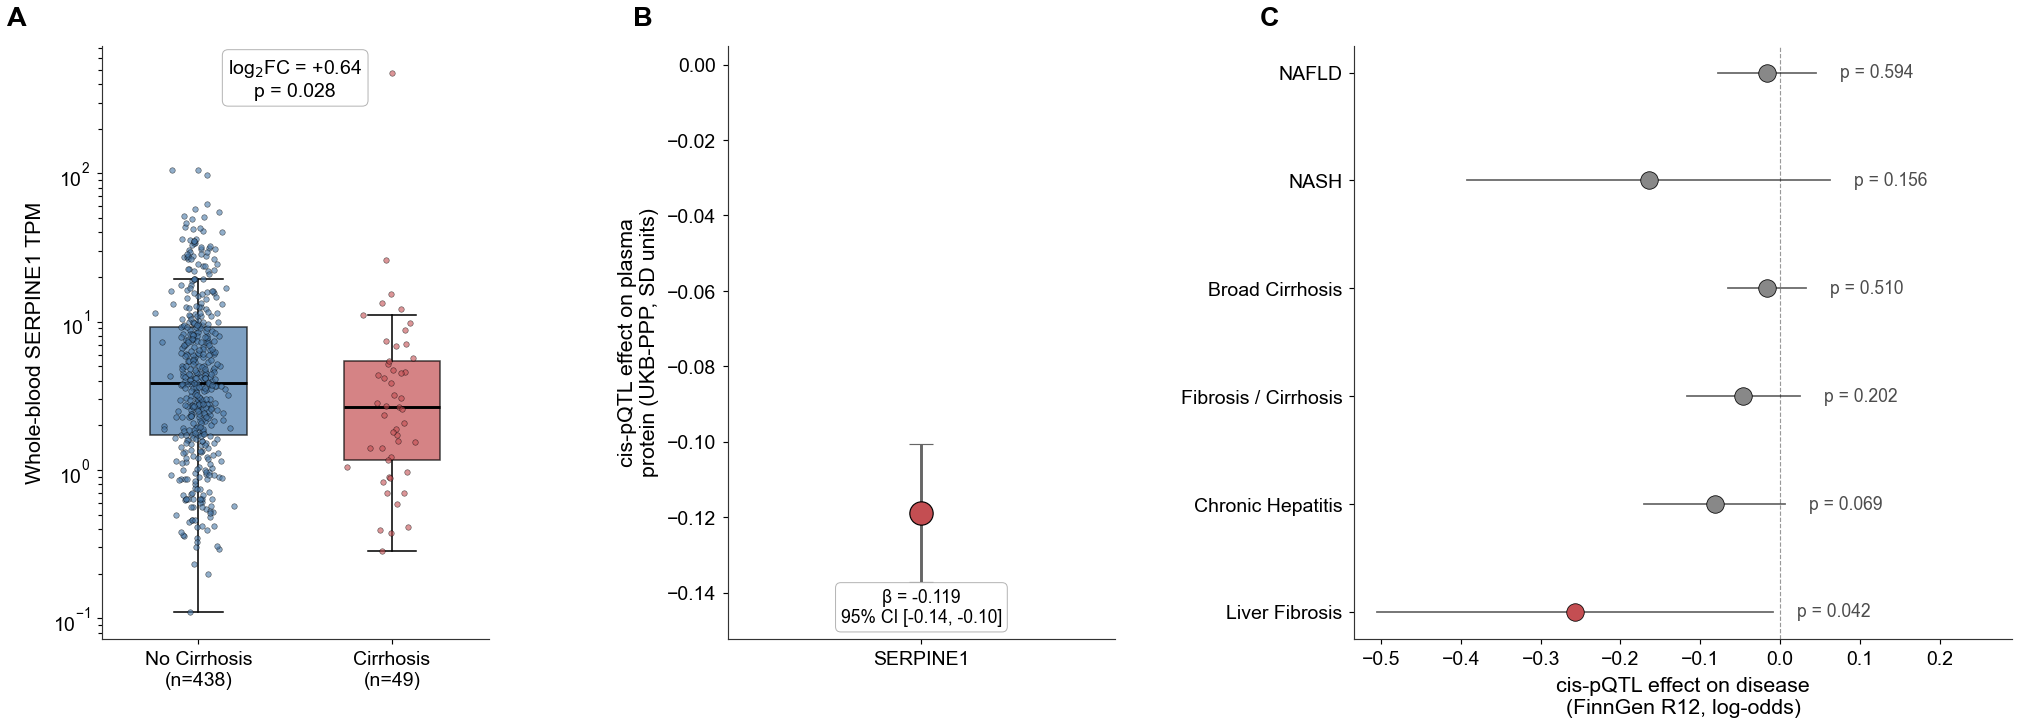

In [6]:
from scipy.stats import mannwhitneyu

GENE = "SERPINE1"
ST7_FILE = Config.RAW_DIR / "41586_2023_6592_MOESM3_ESM.xlsx"

blood_tpm = pd.read_parquet(Config.CACHE_DIR / "blood_tpm.parquet")
b_samp_cols = [c for c in blood_tpm.columns if c.startswith("GTEX-")]
b_gene_col = "gene_name" if "gene_name" in blood_tpm.columns else "Description"
blood_vals = blood_tpm.loc[blood_tpm[b_gene_col] == GENE, b_samp_cols].iloc[0].astype(float)

lab = pd.read_csv(Config.PROCESSED_DIR / "liver_pathology_labels_imputed.csv")
lab["has_cirrhosis"] = (
    lab["Pathology.Categories.Final"].fillna("")
    .str.contains("cirrhosis", case=False, na=False)
    .astype(int)
)
donor_cirr = lab.groupby("Subject.ID")["has_cirrhosis"].max().to_dict()

def _subj(sampid):
    p = sampid.split("-")
    return f"{p[0]}-{p[1]}"

b_df = pd.DataFrame({
    "sampid": b_samp_cols,
    "subj":   [_subj(s) for s in b_samp_cols],
    "tpm":    blood_vals.values,
})
b_df["cirr"] = b_df["subj"].map(donor_cirr)
b_df = b_df.dropna(subset=["cirr"]).astype({"cirr": int})
b_pos = b_df.loc[b_df.cirr == 1, "tpm"].values
b_neg = b_df.loc[b_df.cirr == 0, "tpm"].values
b_stat, b_p = mannwhitneyu(b_pos, b_neg, alternative="two-sided")
b_log2fc = np.log2((b_pos.mean() + 1) / (b_neg.mean() + 1))
print(f"Blood {GENE}: pos={len(b_pos)}, neg={len(b_neg)}, log2FC={b_log2fc:+.2f}, p={b_p:.2e}")

# --- MR + cis-pQTL exposure SE ---------------------------------------------
mr = pd.read_csv(Config.TABLES_DIR / "mr_blood_cirrhosis_up100_same_direction.csv")
mr_g = mr[mr.Gene == GENE].copy()
st9 = pd.read_excel(ST7_FILE, sheet_name="ST9", header=4)
st9["gene_symbol"] = st9["UKBPPP ProteinID"].astype(str).str.split(":").str[0]
se_exp = float(st9[(st9.gene_symbol == GENE) & (st9["cis/trans"] == "cis")]["SE (discovery)"].iloc[0])
beta_exp = float(mr_g["beta_exp"].iloc[0])
print(f"MR {GENE}: beta_exp={beta_exp:+.3f}, SE_exp={se_exp:.4f}, {len(mr_g)} phenotype tests")

# --- Style + phenotype ordering --------------------------------------------
LABEL_FS = 11; TICK_FS = 10; TITLE_FS = 12; PANEL_LETTER_FS = 14
COL_POS, COL_NEG = CORAL, STEEL
PHEN_ORDER = ["NAFLD", "NASH", "CIRRHOSIS_BROAD", "K11_FIBROCHIRLIV", "CHIRHEP_NAS", "FIBROLIV"]
PHEN_LABEL = {
    "NAFLD": "NAFLD", "NASH": "NASH",
    "CIRRHOSIS_BROAD": "Broad Cirrhosis", "K11_FIBROCHIRLIV": "Fibrosis / Cirrhosis",
    "CHIRHEP_NAS": "Chronic Hepatitis", "FIBROLIV": "Liver Fibrosis",
}

# --- Layout: three panels in a horizontal strip ----------------------------
fig = plt.figure(figsize=(15, 5.5))
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.0, 1.7], wspace=0.5,
                     left=0.06, right=0.97, top=0.92, bottom=0.15)

# =========================================== (A) Blood expression box plot
axA = fig.add_subplot(gs[0, 0])
bp = axA.boxplot([b_neg, b_pos], positions=[0, 1], widths=0.5, patch_artist=True,
                 showfliers=False, medianprops=dict(color="black", lw=1.5),
                 boxprops=dict(lw=0.8), whiskerprops=dict(lw=0.8), capprops=dict(lw=0.8))
for patch, col in zip(bp["boxes"], [COL_NEG, COL_POS]):
    patch.set_facecolor(col); patch.set_alpha(0.7); patch.set_edgecolor("black")
rng = np.random.default_rng(0)
for i, (vals, col) in enumerate(zip([b_neg, b_pos], [COL_NEG, COL_POS])):
    jx = rng.normal(loc=i, scale=0.06, size=len(vals))
    axA.scatter(jx, vals, s=8, color=col, alpha=0.6,
                edgecolor="black", linewidth=0.3, zorder=3)
axA.set_xticks([0, 1])
axA.set_xticklabels([f"No Cirrhosis\n(n={len(b_neg)})", f"Cirrhosis\n(n={len(b_pos)})"],
                   fontsize=TICK_FS)
axA.set_ylabel(f"Whole-blood {GENE} TPM", fontsize=LABEL_FS)
axA.set_yscale("log")
axA.tick_params(axis="y", labelsize=TICK_FS)
thin_spines(axA)
_p_str = f"p = {b_p:.2e}" if b_p < 1e-3 else f"p = {b_p:.3f}"
axA.text(0.5, 0.98, f"log$_2$FC = {b_log2fc:+.2f}\n{_p_str}",
         transform=axA.transAxes, ha="center", va="top", fontsize=TICK_FS,
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", lw=0.5))

# =========================================== (B) cis-pQTL exposure instrument
axB = fig.add_subplot(gs[0, 1])
axB.errorbar([0], [beta_exp], yerr=[[1.96 * se_exp], [1.96 * se_exp]],
             fmt="o", color=COL_POS, markersize=12,
             markeredgecolor="black", markeredgewidth=0.6,
             ecolor="0.4", elinewidth=1.5, capsize=6, capthick=1.2)
axB.set_xticks([0])
axB.set_xticklabels([GENE], fontsize=TICK_FS)
axB.set_ylabel("cis-pQTL effect on plasma\nprotein (UKB-PPP, SD units)", fontsize=LABEL_FS)
axB.tick_params(axis="y", labelsize=TICK_FS)
axB.set_xlim(-0.7, 0.7)
thin_spines(axB)
ci_lo = beta_exp - 1.96 * se_exp
ci_hi = beta_exp + 1.96 * se_exp
axB.set_ylim(ci_lo - 0.015, 0.005)
axB.text(0.5, 0.02, f"β = {beta_exp:+.3f}\n95% CI [{ci_lo:+.2f}, {ci_hi:+.2f}]",
         transform=axB.transAxes, ha="center", va="bottom", fontsize=TICK_FS - 1,
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", lw=0.5))

# =========================================== (C) β_out forest across 6 FinnGen phenotypes
axC = fig.add_subplot(gs[0, 2])
mr_ord = mr_g.set_index("Phenotype").reindex(PHEN_ORDER).reset_index()
mr_ord = mr_ord.iloc[::-1].reset_index(drop=True)
y = np.arange(len(mr_ord))
for yi, (_, row) in enumerate(mr_ord.iterrows()):
    b, se, pv = row.beta_out, row.SE, row.p_MR
    col = COL_POS if pv < 0.05 else GRAY
    axC.plot([b - 1.96 * se, b + 1.96 * se], [yi, yi], color="0.4", lw=0.9)
    axC.plot(b, yi, "o", color=col, markersize=9,
             markeredgecolor="black", markeredgewidth=0.4)
    axC.text(b + 1.96 * se + 0.03, yi, f"p = {pv:.3f}",
             va="center", fontsize=TICK_FS - 1, color="0.30")
axC.axvline(0, color="black", ls="--", lw=0.6, alpha=0.4)
axC.set_yticks(y)
axC.set_yticklabels([PHEN_LABEL[p] for p in mr_ord.Phenotype], fontsize=TICK_FS)
axC.set_xlabel("cis-pQTL effect on disease\n(FinnGen R12, log-odds)", fontsize=LABEL_FS)
axC.tick_params(axis="x", labelsize=TICK_FS)
thin_spines(axC)
axC.set_xlim(axC.get_xlim()[0], axC.get_xlim()[1] + 0.2)

# --- Panel letters ---
for ax, letter in [(axA, "A"), (axB, "B"), (axC, "C")]:
    pos = ax.get_position()
    fig.text(pos.x0 - 0.045, pos.y1 + 0.02, letter,
             fontsize=PANEL_LETTER_FS, fontweight="bold", va="bottom", ha="left")

save_fig(fig, "figure_6.pdf"); plt.show()


# Figure 7 — External validation on GSE142255 (Weiss et al. 2021, Front Immunol)

Apply the Liver-cirrhosis PC-derived blood signature to an independent 46-sample clinical cohort: (A) composite score across 6 severity groups; (B) external vs in-cohort AUC; (C) robustness across K = 50/100/200 top genes.

External replication (K=100): vs healthy=0.797, vs septic=0.641, GTEx in-cohort=0.790


  saved figure_7.pdf  (46 KB)


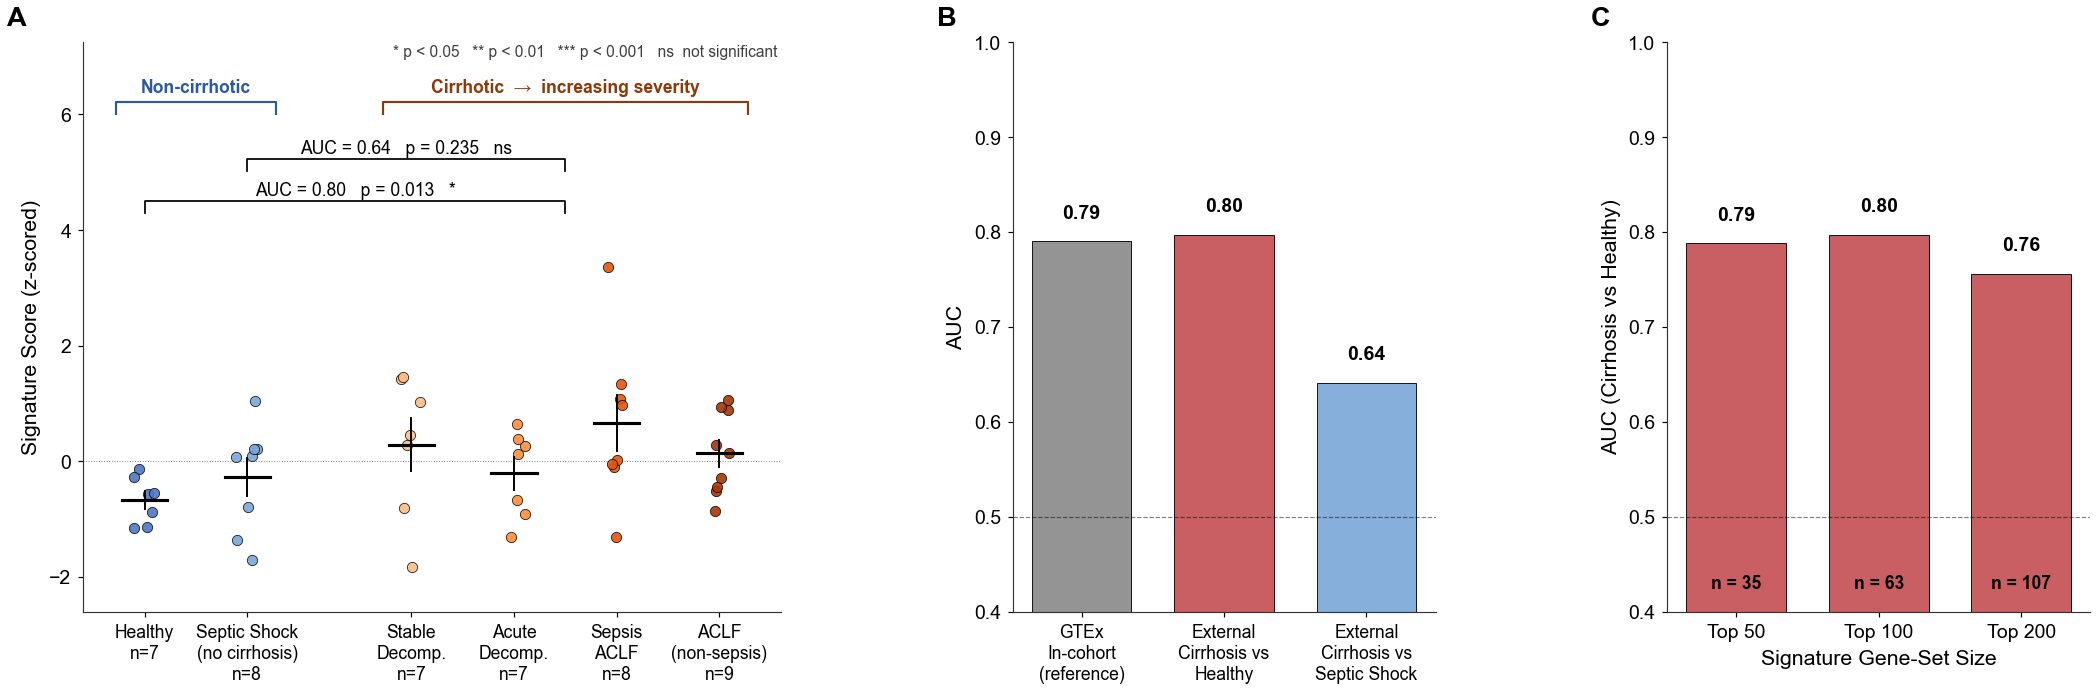

In [7]:
from scipy.stats import mannwhitneyu

SCORES = pd.read_csv(Config.TABLES_DIR / "external_scores_liver_cirrhosis_GSE142255.csv")
VAL    = pd.read_csv(Config.TABLES_DIR / "external_validation_liver_cirrhosis_GSE142255.csv")

# GTEx in-cohort AUC for Liver-cirrhosis, computed inside the CV pipeline (NB10).
GTEX_INCOHORT_AUC = float(
    pc_auc.loc[
        (pc_auc["tissue"] == "Liver") & (pc_auc["category"] == "cirrhosis"),
        "auc_pc_conf"
    ].iloc[0]
)

# z-normalize composite score for panel A visualization
SCORES = SCORES.copy()
SCORES["z"] = (SCORES["signature_score"] - SCORES["signature_score"].mean()) / SCORES["signature_score"].std(ddof=1)

# Severity ordering + colors (cool for non-cirrhotic, warm gradient for cirrhosis)
GROUP_ORDER = [
    "Healthy subject",
    "Septic shock W/O cirrhosis",
    "Stable decompensated cirrhosis",
    "Acute decompensation",
    "Sepsis-induced ACLF",
    "ACLF unrelated to sepsis",
]
SHORT = {
    "Healthy subject":                "Healthy",
    "Septic shock W/O cirrhosis":     "Septic Shock\n(no cirrhosis)",
    "Stable decompensated cirrhosis": "Stable\nDecomp.",
    "Acute decompensation":           "Acute\nDecomp.",
    "Sepsis-induced ACLF":            "Sepsis\nACLF",
    "ACLF unrelated to sepsis":       "ACLF\n(non-sepsis)",
}
COLORS = {
    "Healthy subject":                "#4C78C7",
    "Septic shock W/O cirrhosis":     "#7AA7D9",
    "Stable decompensated cirrhosis": "#FDBE85",
    "Acute decompensation":           "#FD8D3C",
    "Sepsis-induced ACLF":            "#E6550D",
    "ACLF unrelated to sepsis":       "#A63603",
}

# --- Significance stars helper ---------------------------------------------
def _stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

# --- Stats for panel-A brackets --------------------------------------------
z_healthy = SCORES.loc[SCORES["source_name"] == "Healthy subject", "z"].values
z_septic  = SCORES.loc[SCORES["source_name"] == "Septic shock W/O cirrhosis", "z"].values
z_cirr    = SCORES.loc[SCORES["label_binary"] == 1, "z"].values
p_vs_healthy = mannwhitneyu(z_cirr, z_healthy, alternative="two-sided").pvalue
p_vs_septic  = mannwhitneyu(z_cirr, z_septic,  alternative="two-sided").pvalue
pfmt = lambda p: (f"p = {p:.1e}" if p < 1e-3 else f"p = {p:.3f}")

# Headline K=100 AUCs
row_k100 = VAL[VAL.K == 100].iloc[0]
auc_ext_healthy = float(row_k100.AUC_vs_healthy_only)
auc_ext_septic  = float(row_k100.AUC_vs_septicshock_only)
print(f"External replication (K=100): vs healthy={auc_ext_healthy:.3f}, vs septic={auc_ext_septic:.3f}, GTEx in-cohort={GTEX_INCOHORT_AUC:.3f}")

# --- Layout ----------------------------------------------------------------
TICK_FS = 10; LABEL_FS = 11; TITLE_FS = 12; PANEL_LETTER_FS = 14
fig = plt.figure(figsize=(15.5, 5.5))
gs = fig.add_gridspec(
    1, 3, width_ratios=[1.65, 1.0, 1.0], wspace=0.45,
    left=0.055, right=0.98, top=0.94, bottom=0.20,
)

# ============================================== (A) Severity strip plot
axA = fig.add_subplot(gs[0, 0])
rng = np.random.default_rng(0)
x_pos = np.arange(len(GROUP_ORDER), dtype=float)
x_pos[2:] += 0.6  # visual gap between non-cirrhotic and cirrhotic blocks
ns = []
for xi, g in zip(x_pos, GROUP_ORDER):
    vals = SCORES.loc[SCORES["source_name"] == g, "z"].values
    ns.append(len(vals))
    jitter = rng.uniform(-0.11, 0.11, size=len(vals))
    axA.scatter(xi + jitter, vals, s=28, color=COLORS[g],
                edgecolor="black", linewidth=0.4, alpha=0.9, zorder=3)
    m = vals.mean(); se = vals.std(ddof=1) / np.sqrt(len(vals))
    axA.plot([xi - 0.22, xi + 0.22], [m, m], color="black", lw=1.6, zorder=4)
    axA.plot([xi, xi], [m - se, m + se], color="black", lw=1.0, zorder=4)

axA.set_xticks(x_pos)
axA.set_xticklabels([f"{SHORT[g]}\nn={n}" for g, n in zip(GROUP_ORDER, ns)],
                    fontsize=TICK_FS - 1)
axA.set_ylabel("Signature Score (z-scored)", fontsize=LABEL_FS)
axA.set_xlim(x_pos[0] - 0.6, x_pos[-1] + 0.6)
axA.axhline(0, color="grey", lw=0.5, ls=":", zorder=1)
axA.tick_params(axis="y", labelsize=TICK_FS)
thin_spines(axA)

# Group brackets + significance annotations
ymax = SCORES["z"].max(); ymin = SCORES["z"].min(); yspan = ymax - ymin
bracket_y = ymax + 0.55 * yspan; tick = 0.04 * yspan
def _bracket(x0, x1, y, label, color):
    axA.plot([x0, x0, x1, x1], [y - tick, y, y, y - tick], color=color, lw=1.1, clip_on=False)
    axA.text((x0 + x1) / 2, y + 0.02 * yspan, label, ha="center", va="bottom",
             fontsize=TICK_FS - 1, color=color, fontweight="bold")
_bracket(x_pos[0] - 0.28, x_pos[1] + 0.28, bracket_y, "Non-cirrhotic", "#2C5AA0")
_bracket(x_pos[2] - 0.28, x_pos[5] + 0.28, bracket_y,
         "Cirrhotic  →  increasing severity", "#8B3A0A")

cirr_mid = np.mean(x_pos[2:])
sig1_y = ymax + 0.22 * yspan; sig2_y = ymax + 0.36 * yspan
def _sig(x0, x1, y, txt):
    axA.plot([x0, x0, x1, x1], [y - tick, y, y, y - tick], color="black", lw=0.9, clip_on=False)
    axA.text((x0 + x1) / 2, y + 0.005 * yspan, txt,
             ha="center", va="bottom", fontsize=TICK_FS - 1)
_sig(x_pos[0], cirr_mid, sig1_y,
     f"AUC = {auc_ext_healthy:.2f}   {pfmt(p_vs_healthy)}   {_stars(p_vs_healthy)}")
_sig(x_pos[1], cirr_mid, sig2_y,
     f"AUC = {auc_ext_septic:.2f}   {pfmt(p_vs_septic)}   {_stars(p_vs_septic)}")
axA.set_ylim(ymin - 0.15 * yspan, bracket_y + 0.20 * yspan)

# Star-code legend (Panel A, top-right corner)
axA.text(0.995, 0.995,
         "* p < 0.05   ** p < 0.01   *** p < 0.001   ns  not significant",
         transform=axA.transAxes, ha="right", va="top",
         fontsize=TICK_FS - 2, color="0.25")

# ============================================== (B) AUC bar chart — replication + specificity
axB = fig.add_subplot(gs[0, 1])
bar_labels = ["GTEx\nIn-cohort\n(reference)",
              "External\nCirrhosis vs\nHealthy",
              "External\nCirrhosis vs\nSeptic Shock"]
bar_vals   = [GTEX_INCOHORT_AUC, auc_ext_healthy, auc_ext_septic]
bar_colors = [GRAY, CORAL, "#7AA7D9"]
bx = np.arange(len(bar_vals))
axB.bar(bx, bar_vals, color=bar_colors, alpha=0.9,
        edgecolor="black", linewidth=0.5, width=0.7)
for xi, v in zip(bx, bar_vals):
    axB.text(xi, v + 0.02, f"{v:.2f}", ha="center", va="bottom",
             color="black", fontsize=TICK_FS, fontweight="bold")
axB.axhline(0.5, color="black", lw=0.6, ls="--", alpha=0.5)
axB.set_xticks(bx)
axB.set_xticklabels(bar_labels, fontsize=TICK_FS - 1)
axB.set_ylabel("AUC", fontsize=LABEL_FS)
axB.set_ylim(0.4, 1.0)
axB.tick_params(axis="y", labelsize=TICK_FS)
thin_spines(axB)

# ============================================== (C) Robustness across gene-set size
axC = fig.add_subplot(gs[0, 2])
K_vals = VAL.K.astype(int).tolist()
K_auc  = VAL.AUC_vs_healthy_only.astype(float).tolist()
K_n    = VAL.n_matched.astype(int).tolist()
cx = np.arange(len(K_vals))
axC.bar(cx, K_auc, color=CORAL, alpha=0.9,
        edgecolor="black", linewidth=0.5, width=0.7)
for xi, v, n in zip(cx, K_auc, K_n):
    axC.text(xi, v + 0.02, f"{v:.2f}", ha="center", va="bottom",
             color="black", fontsize=TICK_FS, fontweight="bold")
    axC.text(xi, 0.42, f"n = {n}", ha="center", va="bottom",
             color="black", fontsize=TICK_FS - 1, fontweight="bold")
axC.axhline(0.5, color="black", lw=0.6, ls="--", alpha=0.5)
axC.set_xticks(cx)
axC.set_xticklabels([f"Top {k}" for k in K_vals], fontsize=TICK_FS)
axC.set_xlabel("Signature Gene-Set Size", fontsize=LABEL_FS)
axC.set_ylabel("AUC (Cirrhosis vs Healthy)", fontsize=LABEL_FS)
axC.set_ylim(0.4, 1.0)
axC.tick_params(axis="y", labelsize=TICK_FS)
thin_spines(axC)

# --- Panel letters ---
for ax, letter in [(axA, "A"), (axB, "B"), (axC, "C")]:
    pos = ax.get_position()
    fig.text(pos.x0 - 0.035, pos.y1 + 0.015, letter,
             fontsize=PANEL_LETTER_FS, fontweight="bold", va="bottom", ha="left")

save_fig(fig, "figure_7.pdf"); plt.show()


# Supplementary Figure S1 — Model Comparison Across Screened Pairs

Per-pair mean AUC across all screened tissue-pathology pairs for the 6 model variants; Liver | cirrhosis highlighted.

  saved figure_S1.pdf  (30 KB)


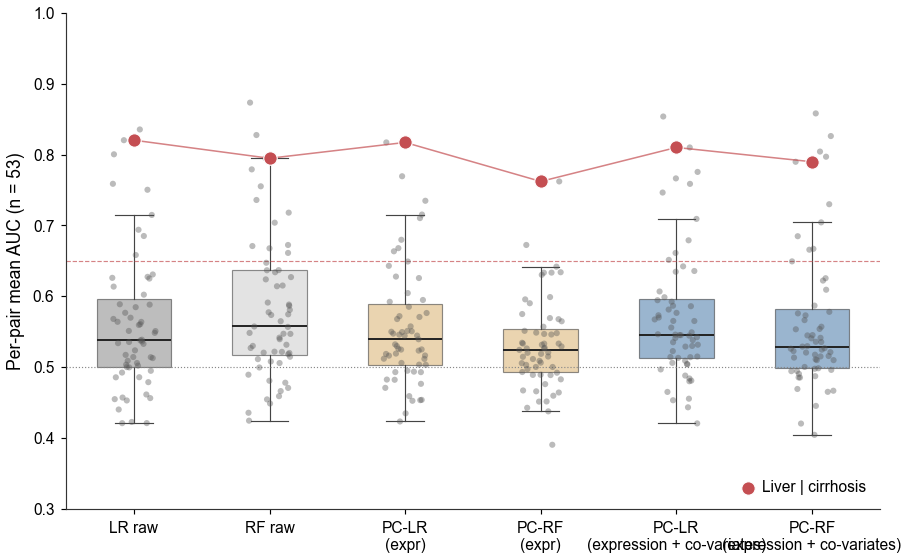

In [8]:
lr_raw = pd.read_csv(Config.TABLES_DIR / "cv_results_all_tissue_pathology.csv")
rf_raw = pd.read_csv(Config.TABLES_DIR / "cv_results_all_tissue_rf.csv")
pc_rf  = pd.read_csv(Config.TABLES_DIR / "pc_auc_results.csv")
pc_lr_ = pd.read_csv(Config.TABLES_DIR / "pc_lr_results.csv")

merged = (lr_raw[["tissue","category","mean_auc"]]
          .rename(columns={"mean_auc": "lr_raw"})
          .merge(rf_raw[["tissue","category","mean_auc"]]
                 .rename(columns={"mean_auc": "rf_raw"}),
                 on=["tissue","category"])
          .merge(pc_lr_[["tissue","category","auc_pc_lr","auc_pc_lr_conf"]],
                 on=["tissue","category"])
          .merge(pc_rf[["tissue","category","auc_pc","auc_pc_conf"]],
                 on=["tissue","category"]))

fig_s1 = plt.figure(figsize=(7.5, 4.6))
ax = fig_s1.add_subplot(1, 1, 1)

model_cols = ["lr_raw", "rf_raw", "auc_pc_lr", "auc_pc", "auc_pc_lr_conf", "auc_pc_conf"]
model_labels = ["LR raw", "RF raw", "PC-LR\n(expr)", "PC-RF\n(expr)",
                "PC-LR\n(expression + co-variates)", "PC-RF\n(expression + co-variates)"]
box_palette = [GRAY, GRAY_LT, GOLD, GOLD, STEEL, STEEL]
positions = np.arange(len(model_cols))

box_data = [merged[c].values for c in model_cols]
bp = ax.boxplot(box_data, positions=positions, widths=0.55, patch_artist=True,
                showfliers=False, medianprops=dict(color="#222", lw=1.0),
                whiskerprops=dict(color="#444", lw=0.6),
                capprops=dict(color="#444", lw=0.6),
                boxprops=dict(lw=0.6))
for box, color in zip(bp["boxes"], box_palette):
    box.set_facecolor(color); box.set_alpha(0.55); box.set_edgecolor("#333")

rng = np.random.default_rng(0)
for i, col in enumerate(model_cols):
    vals = merged[col].values
    jitter = rng.uniform(-0.16, 0.16, len(vals))
    ax.scatter(positions[i] + jitter, vals, s=10, color="#555", alpha=0.4,
               edgecolor="none", zorder=3)

liv = merged[(merged.tissue == "Liver") & (merged.category == "cirrhosis")].iloc[0]
liv_aucs = [liv[c] for c in model_cols]
ax.plot(positions, liv_aucs, color=CORAL, lw=0.8, zorder=4, alpha=0.7)
ax.scatter(positions, liv_aucs, s=48, color=CORAL, edgecolor="white",
           linewidth=0.6, zorder=5, label="Liver | cirrhosis")

ax.axhline(0.5, color=GRAY, ls=":", lw=0.6)
ax.axhline(0.65, color=CORAL, ls="--", lw=0.6, alpha=0.7)
ax.set_xticks(positions); ax.set_xticklabels(model_labels, fontsize=8)
ax.tick_params(axis="y", labelsize=8)
ax.set_ylabel("Per-pair mean AUC (n = 53)", fontsize=9)
ax.set_ylim(0.30, 1.0)
ax.legend(loc="lower right", fontsize=8, frameon=False, handletextpad=0.3)
thin_spines(ax)

save_fig(fig_s1, "figure_S1.pdf"); plt.show()